In [31]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader
from tqdm import tqdm
from torchmetrics.functional import accuracy

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.backends.cudnn.benchmark = True
BATCH_SIZE = 64
EPOCHS = 6

In [32]:
%pip install tensorboard

Note: you may need to restart the kernel to use updated packages.


In [ ]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter('runs/mnist/experiment_6')

# Definindo os Datasets
Alguns datasets comuns encontram-se diretamente em torchvision.datasets

Podemos definir os conjuntos de treino e teste da seguinte forma.

In [34]:
training_data = datasets.MNIST(
    root="data",
    train=True,
    download=True,
    transform=ToTensor(),
)
test_data = datasets.MNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

# Visualizando o dataset
Podemos visualizar algumas instâncias do nosso conjunto de dados

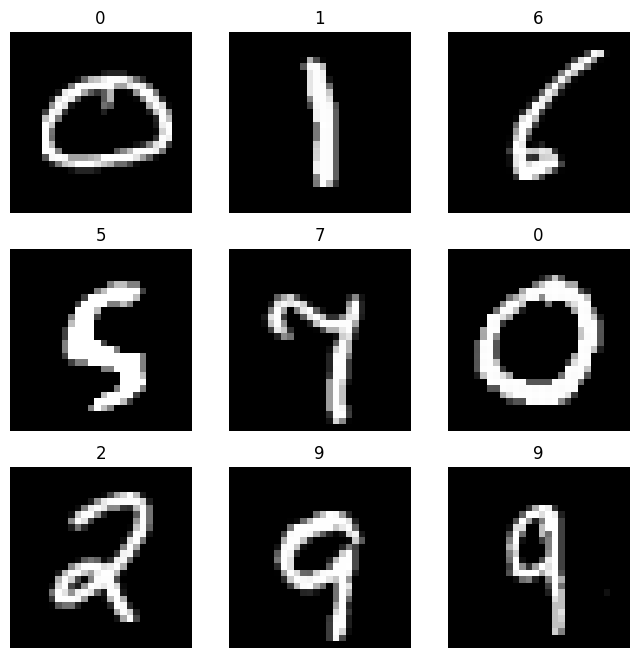

In [35]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In [36]:
train_dataloader = DataLoader(training_data, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print(f"Dataloaders: {train_dataloader, test_dataloader}") 
print(f"Length of train dataloader: {len(train_dataloader)} batches of {BATCH_SIZE}")
print(f"Length of test dataloader: {len(test_dataloader)} batches of {BATCH_SIZE}")

Dataloaders: (<torch.utils.data.dataloader.DataLoader object at 0x7186d0b20fa0>, <torch.utils.data.dataloader.DataLoader object at 0x7186d0b20280>)
Length of train dataloader: 938 batches of 64
Length of test dataloader: 157 batches of 64


In [37]:
x, y = next(iter(test_dataloader))
print(x.shape, y.shape)

torch.Size([64, 1, 28, 28]) torch.Size([64])


In [38]:
class LeNet5(torch.nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, padding=2)
        self.conv2 = torch.nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5)
        self.fc1 = torch.nn.Linear(16*5*5, 120)
        self.fc2 = torch.nn.Linear(120, 84)
        self.fc3 = torch.nn.Linear(84, 10)
        
    def forward(self, x):
        x = torch.max_pool2d(torch.relu(self.conv1(x)), 2)
        x = torch.max_pool2d(torch.relu(self.conv2(x)), 2)
        x = torch.flatten(x, 1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [39]:
torch.manual_seed(42)
lenet5 = LeNet5()
lenet5.to(device)

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)

In [40]:
sample_idx = torch.randint(len(training_data), size=(1,)).item()
img, label = training_data[sample_idx]
writer.add_graph(lenet5, img.unsqueeze(0).to(device))

In [41]:
loss_fn = torch.nn.CrossEntropyLoss() 
optimizer = torch.optim.SGD(params=lenet5.parameters(), lr=0.1)

In [42]:
idxs = torch.randint(len(training_data), size=(1,10))


def save_imgs_to_tensorboard(model, iteration):
    model.eval()
    with torch.no_grad():
        
        figure = plt.figure(figsize=(8, 8))
        cols, rows = 3, 3
        for i in range(1, cols * rows + 1):
            sample_idx = idxs[0,i].item()
            img, label = training_data[sample_idx]
            figure.add_subplot(rows, cols, i)
            predicted = torch.argmax(lenet5(img.unsqueeze(0).to(device)))
            plt.title(f'True: {label} | Pred: {predicted}')
            plt.axis("off")
            plt.imshow(img.squeeze(), cmap="gray")
        writer.add_figure('mnist_images', plt.gcf(), global_step=iteration)
        save_feature_maps_c1_tensorboard(model, iteration)
        save_feature_maps_c2_tensorboard(model, iteration)
    model.train()

def save_feature_maps_c1_tensorboard(model, iteration):
    model.eval()
    with torch.no_grad():
        figure = plt.figure(figsize=(8, 8))
        cols, rows = 3, 3
        for i in range(1, cols * rows + 1):
            sample_idx = idxs[0,i].item()
            img, label = training_data[sample_idx]
            img = img.unsqueeze(0).to(device)
            feature_maps = torch.max_pool2d(torch.relu(model.conv1(img)),2)
            figure.add_subplot(rows, cols, i)
            plt.title(f'Feat. Maps True: {label} | Pred: {feature_maps}')
            plt.axis("off")
            plt.imshow(feature_maps[0,0].cpu(), cmap="gray")
        writer.add_figure('feature_mapsc1', plt.gcf(), global_step=iteration)
        
    model.train()

def save_feature_maps_c2_tensorboard(model, iteration):
    model.eval()
    with torch.no_grad():
        figure = plt.figure(figsize=(8, 8))
        cols, rows = 3, 3
        for i in range(1, cols * rows + 1):
            sample_idx = idxs[0,i].item()
            img, label = training_data[sample_idx]
            img = img.unsqueeze(0).to(device)
            feature_maps = torch.max_pool2d(torch.relu(model.conv1(img)),2)
            feature_maps = torch.max_pool2d(torch.relu(model.conv2(feature_maps)),2)
            figure.add_subplot(rows, cols, i)
            plt.title(f'Feat. Maps True: {label} | Pred: {feature_maps}')
            plt.axis("off")
            plt.imshow(feature_maps[0,0].cpu(), cmap="gray")
        writer.add_figure('feature_mapsc2', plt.gcf(), global_step=iteration)

    model.train()

In [43]:
def train_step(epoch, model, dataloader, loss_fn, optimizer, device: torch.device):
    train_loss = 0
    # Faz loop em todos os dados de treino
    for i, (X, y) in enumerate(dataloader):
        
        X, y = X.to(device), y.to(device)
        model.train() 
        # 1. Forward pass
        y_pred = model(X)

        # 2. Calcula loss por batch
        loss = loss_fn(y_pred, y)
        train_loss += loss.item()
        writer.add_scalar('Loss/train',
                            loss.item(),
                             epoch * len(dataloader) + i)
        writer.add_scalar('Accuracy/train',
                            accuracy(torch.softmax(y_pred,dim=1), 
                                     y,
                                     task='multiclass',
                                     num_classes=10),
                            epoch * len(dataloader) + i)
        if i%100 == 0:
            save_imgs_to_tensorboard(model,epoch * len(dataloader) + i)

        # 3. zera gradientes anteriores
        optimizer.zero_grad()

        # 4. Backward Pass
        loss.backward()

        # 5. Otimizacao
        optimizer.step()

    train_loss /= len(dataloader)
    return train_loss


In [44]:
def test_step(epoch, model:torch.nn.Module, loss_fn:torch.nn.Module, dataloader:torch.utils.data.DataLoader, device:torch.device):
    test_loss, test_acc = 0, 0 
    model.eval()
    with torch.inference_mode():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            # 1. Forward pass
            test_pred = model(X)
        
            # 2. Loss
            test_loss += loss_fn(test_pred, y).item() # accumulatively add up the loss per epoch

            # 3. Computa a acuracia
            test_acc += accuracy(target=y,
                                 preds=torch.softmax(test_pred,dim=1),
                                 task='multiclass',
                                 num_classes=10)
        
        test_loss /= len(dataloader)
        test_acc /= len(dataloader)
        writer.add_scalar('Loss/test', 
                          test_loss,
                          epoch)
        writer.add_scalar('Accuracy/test',
                            test_acc,
                            epoch)
        return test_loss, test_acc

In [ ]:
torch.manual_seed(42)
for epoch in range(EPOCHS):
    with tqdm(train_dataloader, desc=f'{epoch=}', unit='batch') as tqdm_epoch:
        train_loss = train_step(epoch, lenet5, tqdm_epoch, loss_fn, optimizer, device)
        test_loss, test_acc = test_step(epoch, lenet5, loss_fn, test_dataloader, device)
        
    print(f'Train loss: {train_loss:.5f} | Test loss: {test_loss:.5f}, Test acc: {test_acc*100:.4f}%')


epoch=0:  63%|█████████████████████████████████████████████████████████████████████████████████▋                                               | 594/938 [00:17<00:04, 84.25batch/s]

epoch=0:  64%|██████████████████████████████████████████████████████████████████████████████████▌                                              | 600/938 [00:18<00:10, 32.57batch/s]
